<a href="https://colab.research.google.com/github/talitharhmd/Tugas-Akhir/blob/main/Scraping_Preprocessing_Fix.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **00. INSTALL & IMPORT LIBRARIES**
Menginstall dan mengimpor seluruh library yang dibutuhkan untuk data processing, visualisasi, sampai deteksi bahasa, dan export file.

In [1]:
# install package
!pip install nltk
!pip install wordcloud
!pip install langdetect

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 24.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=6c01d58fde3d54baab47e262eb002cd9139ecf664d3e6873a27e9123f0a0f12e
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect


In [6]:
import re
import time
import requests
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from collections import Counter
from nltk.stem import WordNetLemmatizer
from nltk.stem import SnowballStemmer
from nltk import FreqDist

from langdetect import detect
from wordcloud import WordCloud
from urllib.parse import quote

In [7]:
# download resource nltk
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

# **01 Scraping Data**

In [25]:
keywords = [
    "sentiment analysis",
    "topic modeling",
    "time series forecasting",
    "dimensionality reduction",
    "feature selection",
    "predictive analytics"
]

years = [2020, 2021, 2022, 2023, 2024, 2025, 2026]

base_url = "https://doaj.org/api/search/articles/"

unique_articles = {}

for year in years:
    print(f"--- Memproses Tahun: {year} ---")
    for keyword in keywords:
        print(f"Searching: {keyword}...")

        # query: mencari keyword di abstract + filter tahun + kategori teknologi
        query = (
            f'bibjson.abstract:"{keyword}" '
            f'AND bibjson.year:{year} '
            f'AND index.schema_codes_tree.exact:"LCC:T"'
        )

        # endpoint request
        url = f"{base_url}{query}?pageSize=100"

        try:
            response = requests.get(url)

            # jika request berhasil
            if response.status_code == 200:
                data = response.json()
                articles = data.get("results", [])

                # ambil setiap artikel
                for item in articles:
                    bib = item.get("bibjson", {})
                    title = bib.get("title", "")

                    # gunakan judul sebagai kunci unik
                    if title not in unique_articles:
                        unique_articles[title] = {
                            "Main_Keyword": keyword,  # keyword pertama yang menemukan artikel
                            "Year": bib.get("year", year),
                            "Title": title,
                            "Journal": bib.get("journal", {}).get("title", ""),
                            "Abstract": bib.get("abstract", "")
                        }

            else:
                print(f"⚠️ Error {response.status_code} pada keyword {keyword}")

        except Exception as e:
            print(f"Error: {e}")

        # jeda request
        time.sleep(2)

df = pd.DataFrame(list(unique_articles.values()))
print(f"\nSelesai untuk scraping DOAJ!!!")
df.to_csv("doaj_data_science.csv", index=False)

In [26]:
df = pd.read_excel('data_mentah.xlsx')
df.head(20)

,Main_Keyword,Year,Title,Journal,Abstract
0,sentiment analysis,2020,Automatic Visual Sentiment Analysis with Convo...,International Journal of Industrial Engineerin...,Today's digital world demands about automated ...
1,sentiment analysis,2020,Predicting Supervise Machine Learning Performa...,IEEE Access,Sentiment Analysis (SA) is focused on mining o...
2,sentiment analysis,2020,Unsupervised Semantic Approach of Aspect-Based...,IEEE Access,Aspect-based sentiment analysis (ABSA) has rec...
3,sentiment analysis,2020,Exploring Diverse Features for Sentiment Quant...,IEEE Access,"In the era of web 2.0, online forums, blogs an..."
4,sentiment analysis,2020,Evaluation of Sentiment Analysis in Finance: F...,IEEE Access,Financial and economic news is continuously mo...
5,sentiment analysis,2020,Data augmentation with foreign language conten...,Adaptivni Sistemi Avtomatičnogo Upravlinnâ,The object of research is the data augmentatio...
6,sentiment analysis,2020,Stacked Residual Recurrent Neural Networks Wit...,IEEE Access,Text classification is a fundamental task in n...
7,sentiment analysis,2020,Arabic Sentiment Analysis (ASA) Using Deep Lea...,Journal of Engineering,Sentiment analysis is one of the major fields ...
8,sentiment analysis,2020,A Precisely Xtreme-Multi Channel Hybrid Approa...,IEEE Access,In order to accelerate the performance of vari...
9,sentiment analysis,2020,Arabic text summarization using deep learning ...,Journal of Big Data,Abstract Natural language processing has witne...


## **1.1 EDA**
cek informasi dataset untuk melihat jumlah data, tipe data, dan missing value

In [27]:
print(f"Dataset memiliki {df.shape[0]} baris dan {df.shape[1]} kolom\n")

print("="*50)
print("Informasi Dataset")
print("="*50)
df.info()

Dataset memiliki 3347 baris dan 5 kolom

Informasi Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3347 entries, 0 to 3346
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Main_Keyword  3347 non-null   object
 1   Year          3347 non-null   int64 
 2   Title         3347 non-null   object
 3   Journal       3347 non-null   object
 4   Abstract      3347 non-null   object
dtypes: int64(1), object(4)
memory usage: 130.9+ KB


untuk cek missing values pada data

In [28]:
total = df.isnull().sum().sort_values(ascending=False)
percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.concat([total, percent], axis=1)
missing_df.columns = ["Total Missing", "Percent (%)"]
missing_df

,Total Missing,Percent (%)
Main_Keyword,0,0.0
Year,0,0.0
Title,0,0.0
Journal,0,0.0
Abstract,0,0.0


distribusi data untuk per tahun dan distribusi data per keyword

In [ ]:
print("Distibusi Tahun")
print(df["Year"].value_counts().sort_index())

print("Distibusi Keyword")
print(df["Main_Keyword"].value_counts().sort_index())

Distibusi Tahun
Year
2020    386
2021    398
2022    450
2023    479
2024    575
2025    589
2026    470
Name: count, dtype: int64
Distibusi Keyword
Main_Keyword
dimensionality reduction    689
feature selection           663
predictive analytics        373
sentiment analysis          692
time series forecasting     501
topic modeling              429
Name: count, dtype: int64


# **02 Text Preprocessing**

In [ ]:
# mengambil kolom yang relevan untuk preprocessing
df2 = df.copy()
df2 = df2[['Abstract', 'Year']]
df2.tail(50)

,Abstract,Year
3297,Abstract The integration of collaborative robo...,2026
3298,"AI-native, programmable, and disaggregated 6G ...",2026
3299,Unexpected equipment failures in industrial sy...,2026
3300,The development and validation of a comprehens...,2026
3301,Internet-of-Things (IoT) sensing can improve t...,2026
3302,Artificial Intelligence (AI) is increasingly e...,2026
3303,Engineering is suffering a significant change ...,2026
3304,ABSTRACT Ecosystem services (ES) from natural ...,2026
3305,"Project management methodologies like Agile, W...",2026
3306,Machine learning (ML) has emerged as a vital r...,2026


## 2.2 Filtering Bahasa
Membuang bahasa lain selain abstrak berbahasa Inggris.

In [ ]:
# fungsi cek bahasa inggris
def is_english(text):
    try:
        return detect(text) == "en"
    except:
        return False

df2 = df[df["Abstract"].apply(is_english)]

print("Jumlah setelah filter English:", df2.shape)

Jumlah setelah filter English: (3326, 5)


## 2.3 Case Folding & Remove Punctuation

In [ ]:
# mengubah satu token unik (misal: 'sa' jadi 'sentiment_analysis')
acronym_map = {
    r"\bsa\b": "sentiment_analysis",
    r"\babsa\b": "aspect_based_sentiment_analysis",
    r"\basa\b": "arabic_sentiment_analysis",
    r"\bnlp\b": "natural_language_processing",
    r"\bhkt\b": "hierarchical_knowledge_tree",
    r"\btsi\b": "tree_similarity_index",
    r"\btdi\b": "tree_difference_index",
    r"\bsml\b": "supervised_machine_learning",
    r"\bml\b": "machine_learning",
    r"\bdl\b": "deep_learning",
    r"\bcnn\b": "convolutional_neural_network",
    r"\blstm\b": "long_short_term_memory",
    r"\brnn\b": "recurrent_neural_network",
    r"\bsvm\b": "support_vector_machine",
    r"\bknn\b": "k_nearest_neighbors",
    r"\bpca\b": "principal_component_analysis"}

remove_terms = [
    "abstract","background","introduction","objective","objectives",
    "method","methods","conclusion","conclusions","result",
    "study","paper","research","proposed","propose","using","used",
    "approach","framework","feature", "based", "sentiment", "analysis",
    "based", "model", "data", "learning", "network", "system", "process",
    "time"]

def clean_text(text):
    text = str(text).lower()  # lowercase
    text = re.sub(r"'s\b", "", text) # hapus possessive
    text = text.replace("-", " ") # normalisasi tanda hubung

    # gabungkan frasa penting
    phrases = [
        ("aspect based sentiment analysis", "aspect_based_sentiment_analysis"),
        ("sentiment analysis", "sentiment_analysis"),
        ("machine learning", "machine_learning"),
        ("deep learning", "deep_learning"),
        ("principal component analysis", "principal_component_analysis"),
        ("natural language processing", "natural_language_processing")]
    for p, r in phrases:
        text = text.replace(p, r)

    # ekspansi akronim
    sorted_acronyms = sorted(acronym_map.keys(), key=len, reverse=True)
    for acronym in sorted_acronyms:
        text = re.sub(acronym, acronym_map[acronym], text)

    # hapus karakter non-huruf
    text = re.sub(r'[\x00-\x1F\x7F]', ' ', text)
    text = re.sub(r"<.*?>", " ", text) # html
    text = re.sub(r"_x000d_", " ", text)
    text = re.sub(r"http\S+|www\S+", " ", text) # url
    text = re.sub(r"[^a-z\s_]", " ", text) # angka & simbol dihapus

    # hapus remove_terms
    pattern = r"\b(" + "|".join(remove_terms) + r")\b"
    text = re.sub(pattern, " ", text)
    text = re.sub(r'\b(\w+)(?:\s+\1\b)+', r'\1', text)
    text = re.sub(r"\s+", " ", text).strip() # hapus spasi berlebih
    return text

df2["clean_text"] = df2["Abstract"].apply(clean_text)
df2.tail(20)

/tmp/ipykernel_10934/4173846920.py:63: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2["clean_text"] = df2["Abstract"].apply(clean_text)


,Main_Keyword,Year,Title,Journal,Abstract,clean_text
3327,predictive analytics,2026,An Open-Source AI-as-a-Service Framework for F...,IEEE Access,The rise of edge computing has enabled diverse...,the rise of edge computing has enabled diverse...
3328,predictive analytics,2026,Performance Monitoring of Photovoltaic Modules...,Energy Science & Engineering,ABSTRACT Performance monitoring is a major iss...,performance monitoring is a major issue for so...
3329,predictive analytics,2026,Enhanced 1D Convolutional Neural Network for s...,Ain Shams Engineering Journal,Obesity has emerged as a significant public he...,obesity has emerged as a significant public he...
3330,predictive analytics,2026,A predictive analytics framework for South Afr...,Frontiers in Sustainable Food Systems,IntroductionSouth Africa’s land redistribution...,introductionsouth africa s land redistribution...
3331,predictive analytics,2026,Renewable Energy and Resource Recovery Systems...,ITEGAM-JETIA,\nThe global energy transition toward sustaina...,the global energy transition toward sustainabi...
3332,predictive analytics,2026,Structural Health Monitoring and Predictive Ma...,e-Journal of Nondestructive Testing,\nThis paper explores the transformative poten...,this explores the transformative potential of ...
3333,predictive analytics,2026,CRISP: Cyber-Resilient Intelligent Systems for...,IEEE Access,Security is critical for reliable service deli...,security is critical for reliable service deli...
3334,predictive analytics,2026,From vulnerability to viability: integrating g...,Frontiers in Sustainable Food Systems,The Small Island Developing States (SIDS) are ...,the small island developing states sids are ep...
3335,predictive analytics,2026,Global Carbon Footprint Distribution Modeling ...,IEEE Access,Global carbon footprint distribution poses sig...,global carbon footprint distribution poses sig...
3336,predictive analytics,2026,Recent optimization methods and techniques in ...,Results in Engineering,Residential Home Energy Management System (HEM...,residential home energy management hems has em...


## 2.4 Tokenisasi
Mengubah teks menjadi token (kata per kata).

In [ ]:
df3 = df2.copy()
def tokenizing_text(text):
    return word_tokenize(text)
df3["tokenizing"] = df3["clean_text"].apply(tokenizing_text)
df3

,Main_Keyword,Year,Title,Journal,Abstract,clean_text,tokenizing
0,sentiment analysis,2020,Automatic Visual Sentiment Analysis with Convo...,International Journal of Industrial Engineerin...,Today's digital world demands about automated ...,today digital world demands about automated se...,"[today, digital, world, demands, about, automa..."
1,sentiment analysis,2020,Predicting Supervise Machine Learning Performa...,IEEE Access,Sentiment Analysis (SA) is focused on mining o...,sentiment_analysis is focused on mining opinio...,"[sentiment_analysis, is, focused, on, mining, ..."
2,sentiment analysis,2020,Unsupervised Semantic Approach of Aspect-Based...,IEEE Access,Aspect-based sentiment analysis (ABSA) has rec...,aspect_based_sentiment_analysis has recently a...,"[aspect_based_sentiment_analysis, has, recentl..."
3,sentiment analysis,2020,Exploring Diverse Features for Sentiment Quant...,IEEE Access,"In the era of web 2.0, online forums, blogs an...",in the era of web online forums blogs and twit...,"[in, the, era, of, web, online, forums, blogs,..."
4,sentiment analysis,2020,Evaluation of Sentiment Analysis in Finance: F...,IEEE Access,Financial and economic news is continuously mo...,financial and economic news is continuously mo...,"[financial, and, economic, news, is, continuou..."
...,...,...,...,...,...,...,...
3342,predictive analytics,2026,Beyond calories: climate-change threats to foo...,Food Safety and Risk,Abstract This debate examines how climate chan...,this debate examines how climate change presen...,"[this, debate, examines, how, climate, change,..."
3343,predictive analytics,2026,BIM-Based Digital Twin and Extended Reality fo...,Applied Sciences,The current literature on electrical system ma...,the current literature on electrical maintenan...,"[the, current, literature, on, electrical, mai..."
3344,predictive analytics,2026,Enhancing recruitment strategies with a hybrid...,International Journal of Information Managemen...,This research proposes a hybrid Automated Mach...,this proposes a hybrid automated machine_learn...,"[this, proposes, a, hybrid, automated, machine..."
3345,predictive analytics,2026,AI-Supported Gamification in E-Learning: A Sys...,Information,The rapid expansion of artificial intelligence...,the rapid expansion of artificial intelligence...,"[the, rapid, expansion, of, artificial, intell..."


## Stopword Removal
Menghapus kata umum yang tidak memiliki makna penting

In [ ]:
english_stopwords = set(stopwords.words('english'))

custom_stopwords = {
    'result','one','two','also','may','could','would','many','well',
    'make','made','show','e','g','eg','et','al','non','high','low',
    'article','present','discuss','overview','aim','work','recent',
    'however','therefore','within','since','possible','according',
    'especially','mainly','furthermore','additionally','results',
    "feature", "based",
    'achieve', 'applied', 'available', 'based', 'challenge', 'comparison',
    'different', 'due', 'existing', 'field', 'first', 'focusing', 'further',
    'highly', 'including', 'known', 'large', 'like', 'main', 'major',
    'many', 'new', 'number', 'paper', 'performance', 'previous', 'proposed',
    'provide', 'real', 'recent', 'research', 'result', 'shown', 'significant',
    'study', 'various', 'well', 'within', 'work', 'results', 'result',

    'today', 'digital', 'world', 'demand', 'focused', 'identification', 'text',
    'widely', 'us', 'find', 'moreover', 'dataset', 'without', 'word', 'change',
    'small', 'sized', 'datasets', 'contain', 'massive', 'thus', 'domain',
    'yelp', 'efficient', 'frequency', 'era', 'web', 'online', 'forum', 'blog',
    'becoming', 'sharing', 'view', 'known', 'deal', 'nowadays', 'exploring',
    'explore', 'need', 'effectiveness', 'addition', 'diverse', 'confirm',
    'decision', 'making', 'unavailability', 'general', 'approach', 'fixed',
    'even', 'make', 'use', 'example', 'volume', 'task', 'chosen', 'pic', 'tab',
    'etc', 'question', 'require', 'attention', 'whose', 'take', 'jointly',
    'headline', 'better', 'due', 'improved','problem', 'application', 'explores', 'background', 'the', 'asc', 'uplift',
    'introduction', 'employee', 'increasing', 'objective', 'proposes',
    'endeavour', 'lineage', 'purpose', 'problem', 'introduces', 'aim',
    'aimed', 'context', 'interest', 'present', 'forums', 'blogs', 'recently', 'todays', 'today'
    'two', 'three', 'twos', 'information', 'also'
}

# gabungan nltk dengan custom
all_stopwords = english_stopwords.union(custom_stopwords)

def remove_stopwords(tokens):
    return [word.lower() for word in tokens
            if word.lower() not in all_stopwords]

df3["stopword_removed"] = df3["tokenizing"].apply(remove_stopwords)
df3

,Main_Keyword,Year,Title,Journal,Abstract,clean_text,tokenizing,stopword_removed
0,sentiment analysis,2020,Automatic Visual Sentiment Analysis with Convo...,International Journal of Industrial Engineerin...,Today's digital world demands about automated ...,today digital world demands about automated se...,"[today, digital, world, demands, about, automa...","[demands, automated, sentiment_analysis, visua..."
1,sentiment analysis,2020,Predicting Supervise Machine Learning Performa...,IEEE Access,Sentiment Analysis (SA) is focused on mining o...,sentiment_analysis is focused on mining opinio...,"[sentiment_analysis, is, focused, on, mining, ...","[sentiment_analysis, mining, opinion, classifi..."
2,sentiment analysis,2020,Unsupervised Semantic Approach of Aspect-Based...,IEEE Access,Aspect-based sentiment analysis (ABSA) has rec...,aspect_based_sentiment_analysis has recently a...,"[aspect_based_sentiment_analysis, has, recentl...","[aspect_based_sentiment_analysis, attracted, e..."
3,sentiment analysis,2020,Exploring Diverse Features for Sentiment Quant...,IEEE Access,"In the era of web 2.0, online forums, blogs an...",in the era of web online forums blogs and twit...,"[in, the, era, of, web, online, forums, blogs,...","[twitter, primary, sources, views, opinions, c..."
4,sentiment analysis,2020,Evaluation of Sentiment Analysis in Finance: F...,IEEE Access,Financial and economic news is continuously mo...,financial and economic news is continuously mo...,"[financial, and, economic, news, is, continuou...","[financial, economic, news, continuously, moni..."
...,...,...,...,...,...,...,...,...
3342,predictive analytics,2026,Beyond calories: climate-change threats to foo...,Food Safety and Risk,Abstract This debate examines how climate chan...,this debate examines how climate change presen...,"[this, debate, examines, how, climate, change,...","[debate, examines, climate, presents, complex,..."
3343,predictive analytics,2026,BIM-Based Digital Twin and Extended Reality fo...,Applied Sciences,The current literature on electrical system ma...,the current literature on electrical maintenan...,"[the, current, literature, on, electrical, mai...","[current, literature, electrical, maintenance,..."
3344,predictive analytics,2026,Enhancing recruitment strategies with a hybrid...,International Journal of Information Managemen...,This research proposes a hybrid Automated Mach...,this proposes a hybrid automated machine_learn...,"[this, proposes, a, hybrid, automated, machine...","[hybrid, automated, machine_learning, automl, ..."
3345,predictive analytics,2026,AI-Supported Gamification in E-Learning: A Sys...,Information,The rapid expansion of artificial intelligence...,the rapid expansion of artificial intelligence...,"[the, rapid, expansion, of, artificial, intell...","[rapid, expansion, artificial, intelligence, a..."


In [ ]:
# gabungkan semua token sebelum dihapus stopword
all_tokens = [word.lower() for tokens in df3["tokenizing"] for word in tokens]

word_counts = Counter(all_tokens)
removed_stopwords = {word: count for word, count in word_counts.items() if word in all_stopwords}
stopword_list = [[word, count] for word, count in removed_stopwords.items()]
stopword_list

[['today', 48],
 ['digital', 435],
 ['world', 385],
 ['about', 360],
 ['on', 5765],
 ['and', 27961],
 ['text', 950],
 ['to', 16462],
 ['through', 1030],
 ['many', 370],
 ['like', 290],
 ['achieve', 303],
 ['low', 466],
 ['more', 1060],
 ['due', 522],
 ['also', 975],
 ['major', 208],
 ['challenge', 229],
 ['is', 7518],
 ['a', 12665],
 ['number', 528],
 ['of', 23868],
 ['the', 43342],
 ['this', 6158],
 ['with', 5718],
 ['focused', 130],
 ['identification', 292],
 ['from', 3064],
 ['such', 1517],
 ['as', 4018],
 ['or', 1024],
 ['it', 1716],
 ['widely', 202],
 ['for', 8605],
 ['one', 663],
 ['an', 3109],
 ['that', 5228],
 ['datasets', 1083],
 ['dataset', 1230],
 ['while', 962],
 ['results', 2545],
 ['are', 3735],
 ['especially', 224],
 ['in', 13295],
 ['domain', 425],
 ['there', 384],
 ['no', 143],
 ['same', 184],
 ['performance', 2290],
 ['against', 165],
 ['real', 917],
 ['new', 663],
 ['addition', 284],
 ['previous', 185],
 ['when', 554],
 ['applied', 608],
 ['because', 192],
 ['differe

## 2.5 Lemmatization

In [ ]:
def lemmatize_df(df3):
    lemmatizer = WordNetLemmatizer()

    def lemmatize_tokens(tokens):
        return [lemmatizer.lemmatize(word) for word in tokens]
    df3.loc[:, "lemmatization"] = df3["stopword_removed"].apply(lemmatize_tokens)
    return df3

df3 = lemmatize_df(df3)
#df3.head()
print("Jumlah setelah lemma:", df3.shape)
df3[["lemmatization"]]

Jumlah setelah lemma: (3326, 9)


,lemmatization
0,"[demand, automated, sentiment_analysis, visual..."
1,"[sentiment_analysis, mining, opinion, classifi..."
2,"[aspect_based_sentiment_analysis, attracted, e..."
3,"[twitter, primary, source, view, opinion, comm..."
4,"[financial, economic, news, continuously, moni..."
...,...
3342,"[debate, examines, climate, present, complex, ..."
3343,"[current, literature, electrical, maintenance,..."
3344,"[hybrid, automated, machine_learning, automl, ..."
3345,"[rapid, expansion, artificial, intelligence, a..."


## 2.6 WordCloud


Top 20 kata paling sering:
[('model', 2738), ('accuracy', 2573), ('algorithm', 2337), ('feature', 2157), ('classification', 1902), ('topic', 1860), ('technique', 1764), ('forecasting', 1702), ('prediction', 1682), ('machine_learning', 1645), ('selection', 1564), ('series', 1415), ('sentiment_analysis', 1283), ('detection', 1157), ('reduction', 1127), ('term', 1125), ('dimensionality', 1100), ('neural', 1064), ('x', 1064), ('review', 1047)]


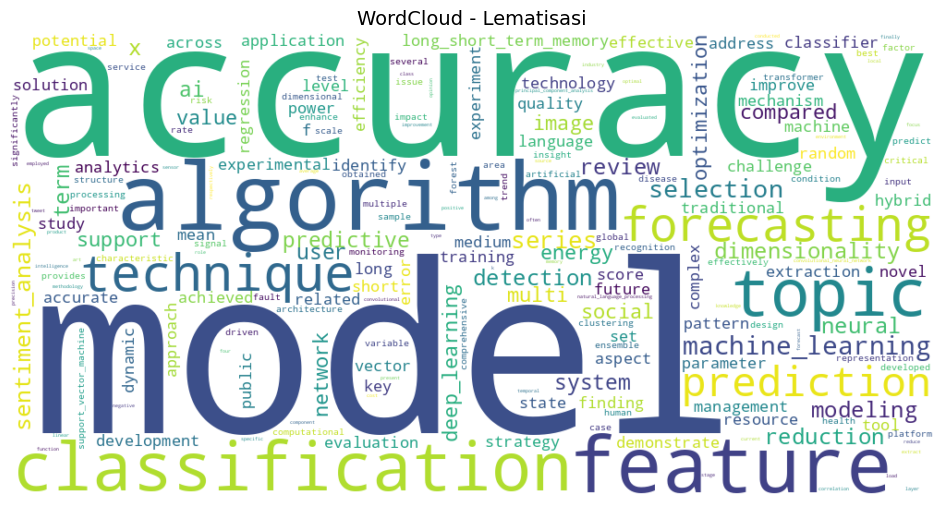

In [ ]:
def wordcloud(token_column, title):
    flat_tokens = [word for sublist in token_column for word in sublist]
    fdist = FreqDist(flat_tokens)

    print("\nTop 20 kata paling sering:")
    print(fdist.most_common(20))

    top_words = dict(fdist.most_common(200))
    wordcloud = WordCloud(width=1000, height=500, background_color="white"
    ).generate_from_frequencies(top_words)

    plt.figure(figsize=(12,6))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(title, fontsize=14)
    plt.show()
    return fdist

fdist_lemma = wordcloud(df3["lemmatization"], "WordCloud - Lematisasi")


Top 20 kata paling sering:
[('models', 2738), ('accuracy', 2497), ('features', 2157), ('classification', 1880), ('forecasting', 1702), ('machine_learning', 1645), ('selection', 1554), ('prediction', 1435), ('series', 1415), ('algorithm', 1369), ('sentiment_analysis', 1283), ('techniques', 1260), ('topic', 1215), ('detection', 1155), ('reduction', 1107), ('dimensionality', 1100), ('neural', 1064), ('x', 1064), ('modeling', 1023), ('systems', 979)]


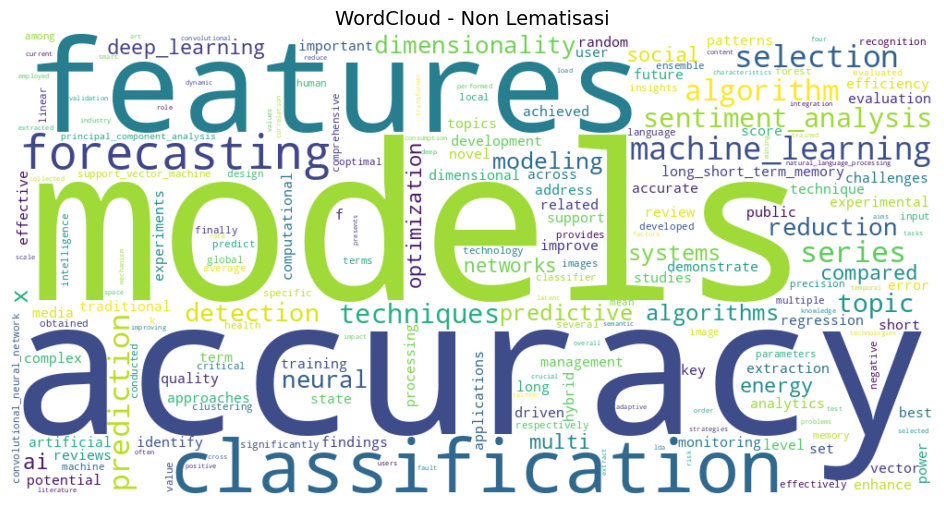

In [ ]:
fdist_lemma = wordcloud(df3["stopword_removed"], "WordCloud - Non Lematisasi")


Top 20 kata paling sering:
[('model', 3875), ('predict', 3525), ('accuraci', 2573), ('algorithm', 2378), ('featur', 2173), ('select', 2160), ('forecast', 2115), ('classif', 1903), ('topic', 1873), ('optim', 1842), ('techniqu', 1764), ('machine_learn', 1645), ('detect', 1586), ('dimension', 1573), ('improv', 1544), ('develop', 1541), ('extract', 1442), ('evalu', 1426), ('seri', 1418), ('compar', 1345)]


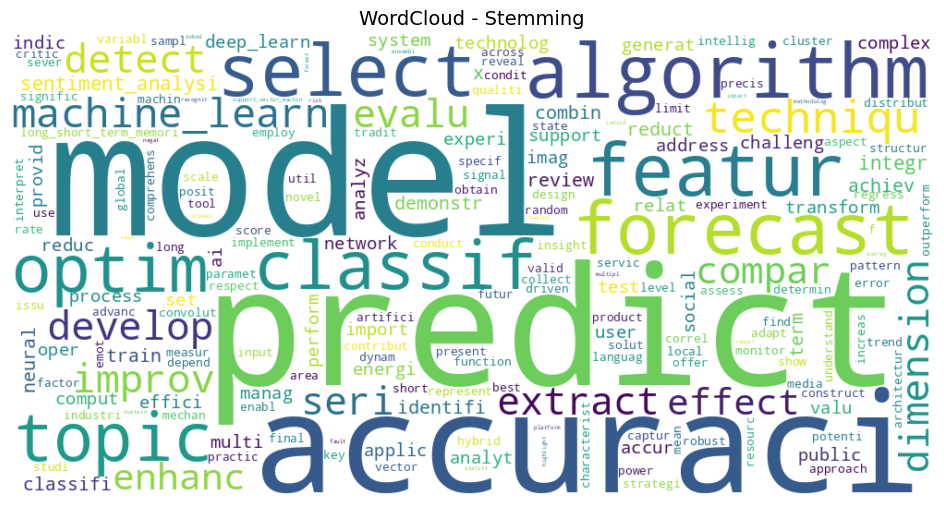

In [ ]:
df4 = df3.copy()
stemmer = SnowballStemmer("english")
def stemming_tokens(tokens):
    return [stemmer.stem(word) for word in tokens]
df4["stemming"] = df4["stopword_removed"].apply(stemming_tokens)
df4[["stemming"]]

fdist_stemming = wordcloud(df4["stemming"], "WordCloud - Stemming")

Interpretasi berdsarkan perbedaan worcloud:


In [ ]:
df_save = df3.copy()
df_save.to_excel("data_clean_doaj_fix.xlsx", index=False)